In [1]:
# Importar librerías
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.18.0


In [2]:
# Cargar y preparar los datos ficticios
# X_reg: Característica (Tamaño en m²)
X_reg = np.array([50, 75, 100, 120, 150, 180, 200, 220, 250, 280, 300, 320, 350, 380, 400]).reshape(-1, 1)

# y_reg: Etiqueta (Precio en miles de $)
y_reg = np.array([150, 200, 250, 280, 320, 360, 400, 430, 480, 520, 550, 580, 620, 660, 700])

# Imprimir la forma de los datos para verificar
print("Forma de X_reg:", X_reg.shape)
print("Forma de y_reg:", y_reg.shape)

Forma de X_reg: (15, 1)
Forma de y_reg: (15,)


In [4]:
# Definir arquitectura de red neuronal
model = keras.Sequential([
    keras.layers.Dense(units=50, activation='relu', input_shape=[1]),
    keras.layers.Dense(units=1)
])

# Mostrar resumen de arquitectura del modelo
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

In [14]:
# Entrenar el modelo
print("Entrenando el modelo...")
history = model.fit(X_reg, y_reg, epochs=50, verbose=0)
print("¡Entrenamiento completado!")

Entrenando el modelo...
¡Entrenamiento completado!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


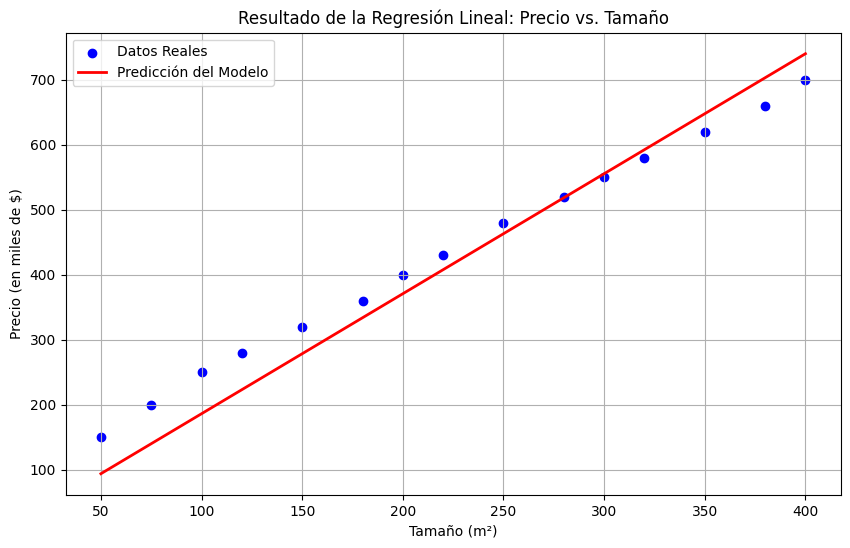

In [16]:
# Realizar predicciones y graficar los resultados
# Hacemos predicciones sobre los mismos datos de entrenamiento para ver cómo se ajusta la línea
predictions = model.predict(X_reg)
# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, label='Datos Reales', color='blue')
plt.plot(X_reg, predictions, label='Predicción del Modelo', color='red', linewidth=2)
plt.title('Resultado de la Regresión Lineal: Precio vs. Tamaño')
plt.xlabel('Tamaño (m²)')
plt.ylabel('Precio (en miles de $)')
plt.legend()
plt.grid(True)
plt.show()